# Introduction

/to be filled and formatted later

# 1. Import libraries

In [2]:
import kagglehub

/Users/alina_yakubova/Scripts_python3/ml-flight-felay-prediction/ml_unibo/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.reset_option("display.max_rows")
pd.set_option("display.float_format", "{:,.0f}".format)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [5]:
import os

# 2. Data import

The following code cell is used to download the dataset files from the Kaggle website. It only needs to be executed once. \
We use library kagglehub, which provides an auth method for logging in through a web page and getting access to Kaggle datasets.

In [6]:
path = kagglehub.dataset_download("threnjen/2019-airline-delays-and-cancellations")

print("Path to dataset files:", path)

Path to dataset files: /Users/alina_yakubova/.cache/kagglehub/datasets/threnjen/2019-airline-delays-and-cancellations/versions/9


In [7]:
df = pd.read_csv(os.path.join(path, "full_data_flightdelay.csv"))

1) General info

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6489062 entries, 0 to 6489061
Data columns (total 26 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   MONTH                          int64  
 1   DAY_OF_WEEK                    int64  
 2   DEP_DEL15                      int64  
 3   DEP_TIME_BLK                   str    
 4   DISTANCE_GROUP                 int64  
 5   SEGMENT_NUMBER                 int64  
 6   CONCURRENT_FLIGHTS             int64  
 7   NUMBER_OF_SEATS                int64  
 8   CARRIER_NAME                   str    
 9   AIRPORT_FLIGHTS_MONTH          int64  
 10  AIRLINE_FLIGHTS_MONTH          int64  
 11  AIRLINE_AIRPORT_FLIGHTS_MONTH  int64  
 12  AVG_MONTHLY_PASS_AIRPORT       int64  
 13  AVG_MONTHLY_PASS_AIRLINE       int64  
 14  FLT_ATTENDANTS_PER_PASS        float64
 15  GROUND_SERV_PER_PASS           float64
 16  PLANE_AGE                      int64  
 17  DEPARTING_AIRPORT              str    
 18  LATITUDE     

# 3. Data understanding

1.2 Descriptive statistics for numerical data

In [21]:
df.describe()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,AIRPORT_FLIGHTS_MONTH,AIRLINE_FLIGHTS_MONTH,AIRLINE_AIRPORT_FLIGHTS_MONTH,AVG_MONTHLY_PASS_AIRPORT,AVG_MONTHLY_PASS_AIRLINE,FLT_ATTENDANTS_PER_PASS,GROUND_SERV_PER_PASS,PLANE_AGE,LATITUDE,LONGITUDE,PRCP,SNOW,SNWD,TMAX,AWND
count,"6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062"
mean,7,4,0,4,3,28,134,"12,685","62,961","3,459","1,588,639","7,814,970",0,0,12,37,-94,0,0,0,71,8
std,3,2,0,2,2,22,46,"8,840","34,382","4,251","1,123,847","5,046,882",0,0,7,6,18,0,0,1,18,4
min,1,1,0,1,1,1,44,"1,100","5,582",1,"70,476","473,794",0,0,0,18,-159,0,0,0,-10,0
25%,4,2,0,2,2,11,90,"5,345","25,034",654,"673,221","2,688,839",0,0,5,33,-106,0,0,0,59,6
50%,7,4,0,3,3,23,143,"11,562","70,878","2,251","1,486,066","8,501,631",0,0,12,38,-88,0,0,0,74,8
75%,10,6,0,5,4,39,172,"17,615","86,312","4,806","2,006,675","12,460,183",0,0,17,41,-81,0,0,0,86,10
max,12,7,1,11,15,109,337,"35,256","117,728","21,837","4,365,661","13,382,999",0,0,32,61,-66,12,17,25,115,34


Descriptive statistics for categorical data

In [22]:
df.describe(include="object")

/var/folders/78/8b3g8thx1b99pgrq0245szkr0000gn/T/ipykernel_26308/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,DEP_TIME_BLK,CARRIER_NAME,DEPARTING_AIRPORT,PREVIOUS_AIRPORT
count,6489062,6489062,6489062,6489062
unique,19,17,96,356
top,0800-0859,Southwest Airlines Co.,Atlanta Municipal,NONE
freq,452391,1296329,392603,1449009


Duplicates

In [9]:
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup:,}  ({n_dup / len(df):.2%})")

Duplicate rows: 28,473  (0.44%)


Drop duplicates

In [24]:
df = df.drop_duplicates().reset_index(drop=True)

Type conversions

- Convert monthes and days of week into strings
- Extract hour from departure time

In [14]:
MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
DOW_ORDER   = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

In [15]:
MONTH_MAP = dict(zip(range(1, 13), MONTH_ORDER))
DOW_MAP   = dict(zip(range(1, 8),  DOW_ORDER))

df["MONTH_NAME"] = pd.Categorical(
    df["MONTH"].map(MONTH_MAP), categories=MONTH_ORDER, ordered=True
)
df["DAY_NAME"] = pd.Categorical(
    df["DAY_OF_WEEK"].map(DOW_MAP), categories=DOW_ORDER, ordered=True
)

In [16]:
df["DEP_HOUR"] = df["DEP_TIME_BLK"].str[:2].astype(int)

df[["MONTH","MONTH_NAME","DAY_OF_WEEK","DAY_NAME",
    "DEP_TIME_BLK","DEP_HOUR"]].head(3)

,MONTH,MONTH_NAME,DAY_OF_WEEK,DAY_NAME,DEP_TIME_BLK,DEP_HOUR
0,1,Jan,7,Sun,0800-0859,8
1,1,Jan,7,Sun,0700-0759,7
2,1,Jan,7,Sun,0600-0659,6


Target distribution (total on-time vs delayed)

In [ ]:
def plot_target_distribution(df, target="DEP_DEL15"):
    """
    Bar chart showing class balance for a binary target column.
    """
    counts = df[target].value_counts().sort_index()
    labels = ["On Time", "Delayed (>15 min)"]
    colors = ["steelblue", "tomato"]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)

    ax.set_ylim(0, max(counts.values) * 1.2)

    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{val:,}\n({val / len(df):.1%})",
            ha="center", va="bottom", fontsize=11,
        )
    ax.set_title("Flight Delay Distribution (DEP_DEL15)", fontsize=13)
    ax.set_ylabel("Number of Flights")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
    plt.tight_layout()
    plt.show()

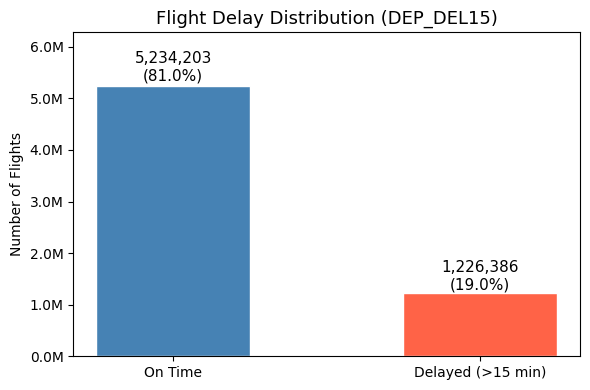

In [41]:
plot_target_distribution(df)

Categorical feature histograms

In [55]:
def plot_categorical_histogram(df, col, top_n=20, figsize=(12, 4),
                               category_order=None):
    """
    Bar chart for a categorical column with delay rate overlay.
    
    col            : column name
    top_n          : keep top N categories by count (ignored if category_order given)
    category_order : explicit list to fix x-axis order (e.g. month names)
    """
    if category_order:
        counts = df[col].value_counts().reindex(category_order).dropna()
    else:
        counts = df[col].value_counts().head(top_n)

    delay_rate = df.groupby(col)["DEP_DEL15"].mean().reindex(counts.index)

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.bar(counts.index.astype(str), counts.values,
            color="steelblue", alpha=0.85, label="Flight Count")
    ax1.set_ylabel("Flight Count", color="steelblue")
    ax1.tick_params(axis="x", rotation=45)
    plt.setp(ax1.get_xticklabels(), ha="right", rotation_mode="anchor")
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K" if x < 1e6 else f"{x/1e6:.1f}M")
    )

    ax2 = ax1.twinx()
    ax2.plot(counts.index.astype(str), delay_rate.values,
             "o-", color="tomato", linewidth=2, label="Delay Rate")
    ax2.set_ylabel("Delay Rate", color="tomato")
    ax2.set_ylim(0, 0.5)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))

    lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax1.legend(lines, labels, loc="upper right", fontsize=8)
    ax1.set_title(f"{col} — Flight Count & Delay Rate", fontsize=11)

    plt.tight_layout()
    plt.show()

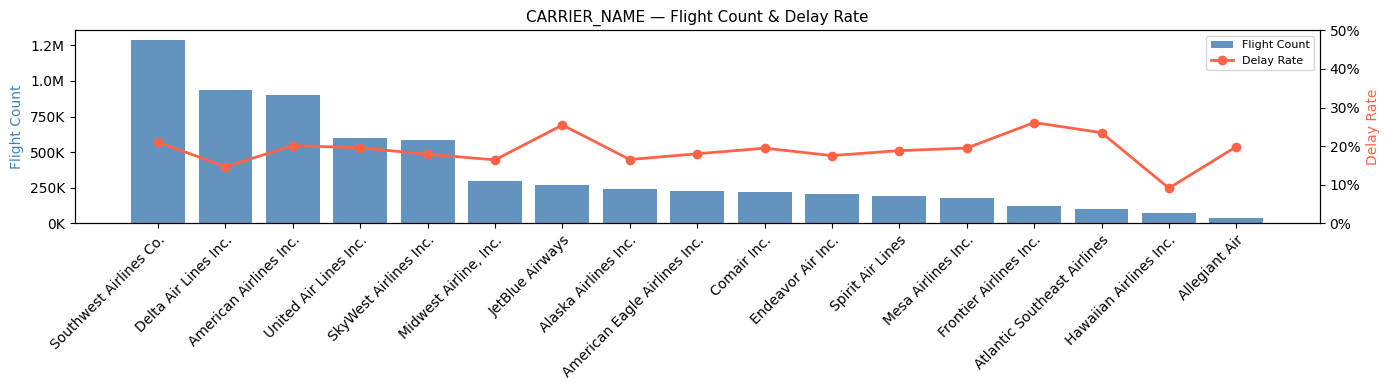

In [ ]:
plot_categorical_histogram(df, "CARRIER_NAME", figsize=(14, 4))

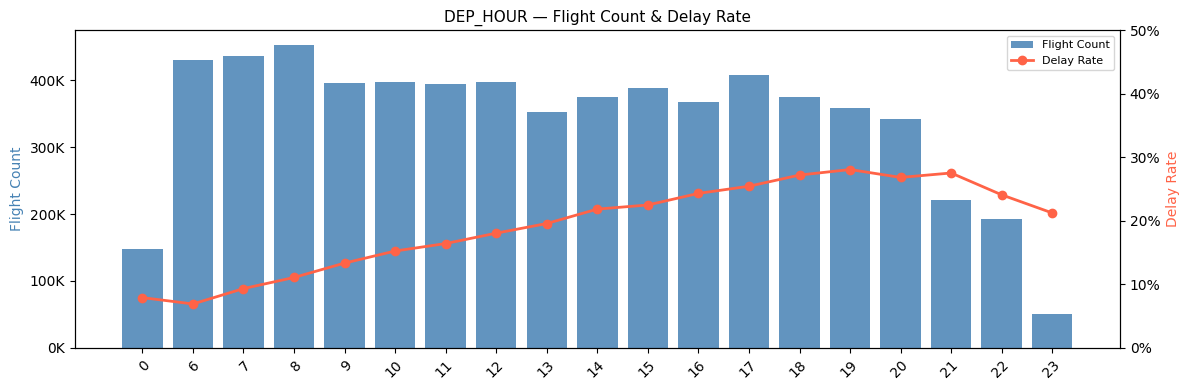

In [57]:
plot_categorical_histogram(df, "DEP_HOUR", category_order = list(range(24)))

Check if there actually is no flight data for the interval: 01-05

In [59]:
df.iloc[df["DEP_HOUR"].isin([1,2,3,4,5])].head(3)

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,AIRLINE_FLIGHTS_MONTH,AIRLINE_AIRPORT_FLIGHTS_MONTH,AVG_MONTHLY_PASS_AIRPORT,AVG_MONTHLY_PASS_AIRLINE,FLT_ATTENDANTS_PER_PASS,GROUND_SERV_PER_PASS,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,MONTH_NAME,DAY_NAME,DEP_HOUR


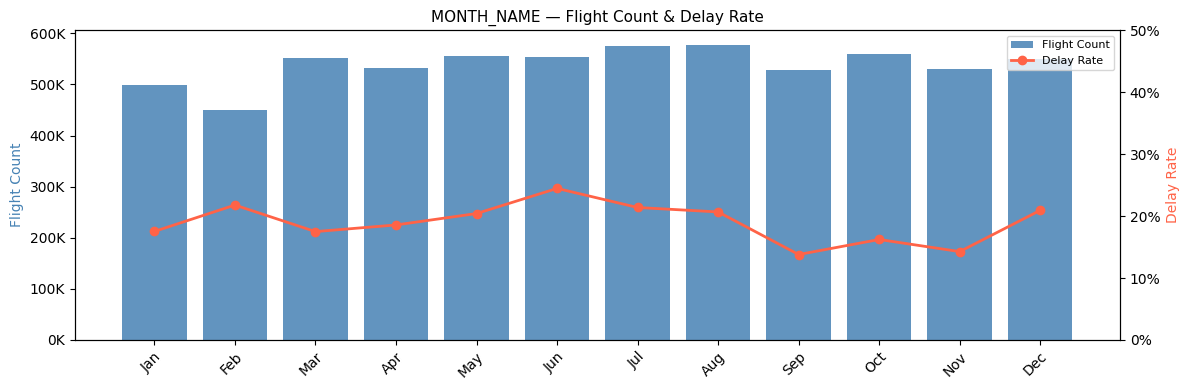

In [49]:
plot_categorical_histogram(df, "MONTH_NAME",  category_order=MONTH_ORDER)

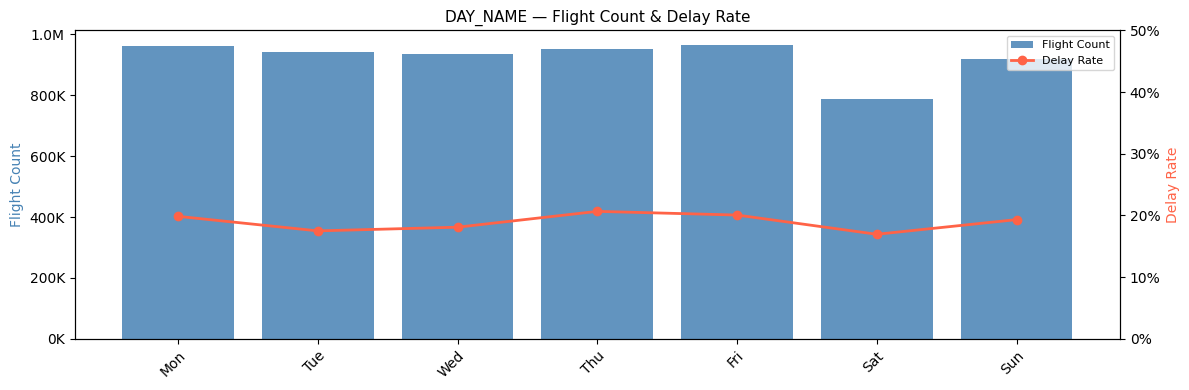

In [50]:
plot_categorical_histogram(df, "DAY_NAME",    category_order=DOW_ORDER)

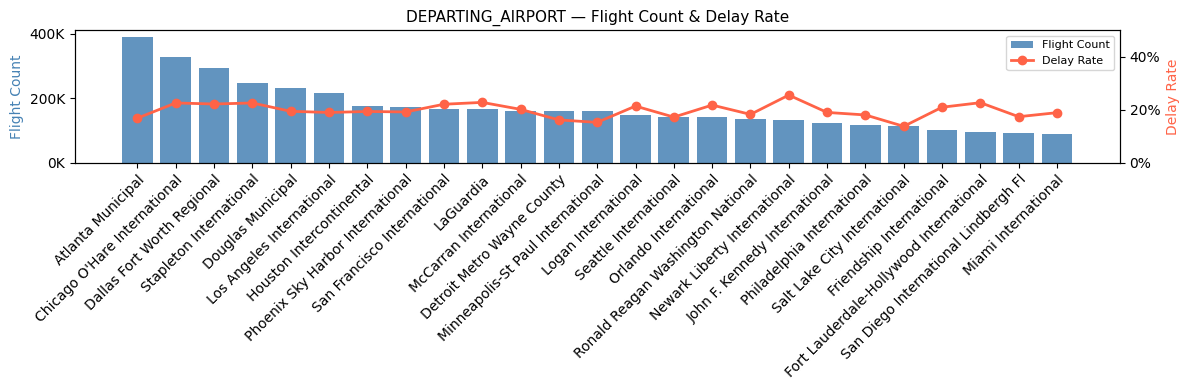

In [51]:
plot_categorical_histogram(df, "DEPARTING_AIRPORT", top_n=25)

Box plot graphs

- Balanced stratified sample for faster boxplot rendering.
- Equal target/non-target counts; fewer outlier points to draw.

In [67]:
SAMPLE_N = 600_000

In [50]:
BOXPLOT_COLS = [
    "CONCURRENT_FLIGHTS", "NUMBER_OF_SEATS", "PLANE_AGE",
    "PRCP", "SNOW", "TMAX", "AWND",
    "SEGMENT_NUMBER", "DISTANCE_GROUP", "DEP_HOUR",
]

In [53]:
def plot_delay_boxplots(df, cols, ncols=2, sample_n=SAMPLE_N):
    '''Grid of boxplots for numeric features split by on-time vs delayed.'''
    on_time = df[df["DEP_DEL15"] == 0].sample(n=min(sample_n // 2, len(df[df["DEP_DEL15"] == 0])), random_state=42)
    delayed = df[df["DEP_DEL15"] == 1].sample(n=min(sample_n // 2, len(df[df["DEP_DEL15"] == 1])), random_state=42)
    sample  = pd.concat([on_time, delayed]).reset_index(drop=True)

    nrows  = (len(cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 9, nrows * 6))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        sns.boxplot(
            data=sample, x="DEP_DEL15", y=col, ax=axes[i],
            hue="DEP_DEL15", palette=["steelblue", "tomato"],
            whis=1.5,
            flierprops=dict(marker=".", markersize=1, alpha=0.2, linestyle="none"),
            legend=False,
        )
        axes[i].set_title(col, fontsize=17)
        axes[i].set_xlabel("0 = On-time  |  1 = Delayed", fontsize=14)
        axes[i].tick_params(labelsize=14)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle("Feature Distributions: On-time vs Delayed", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

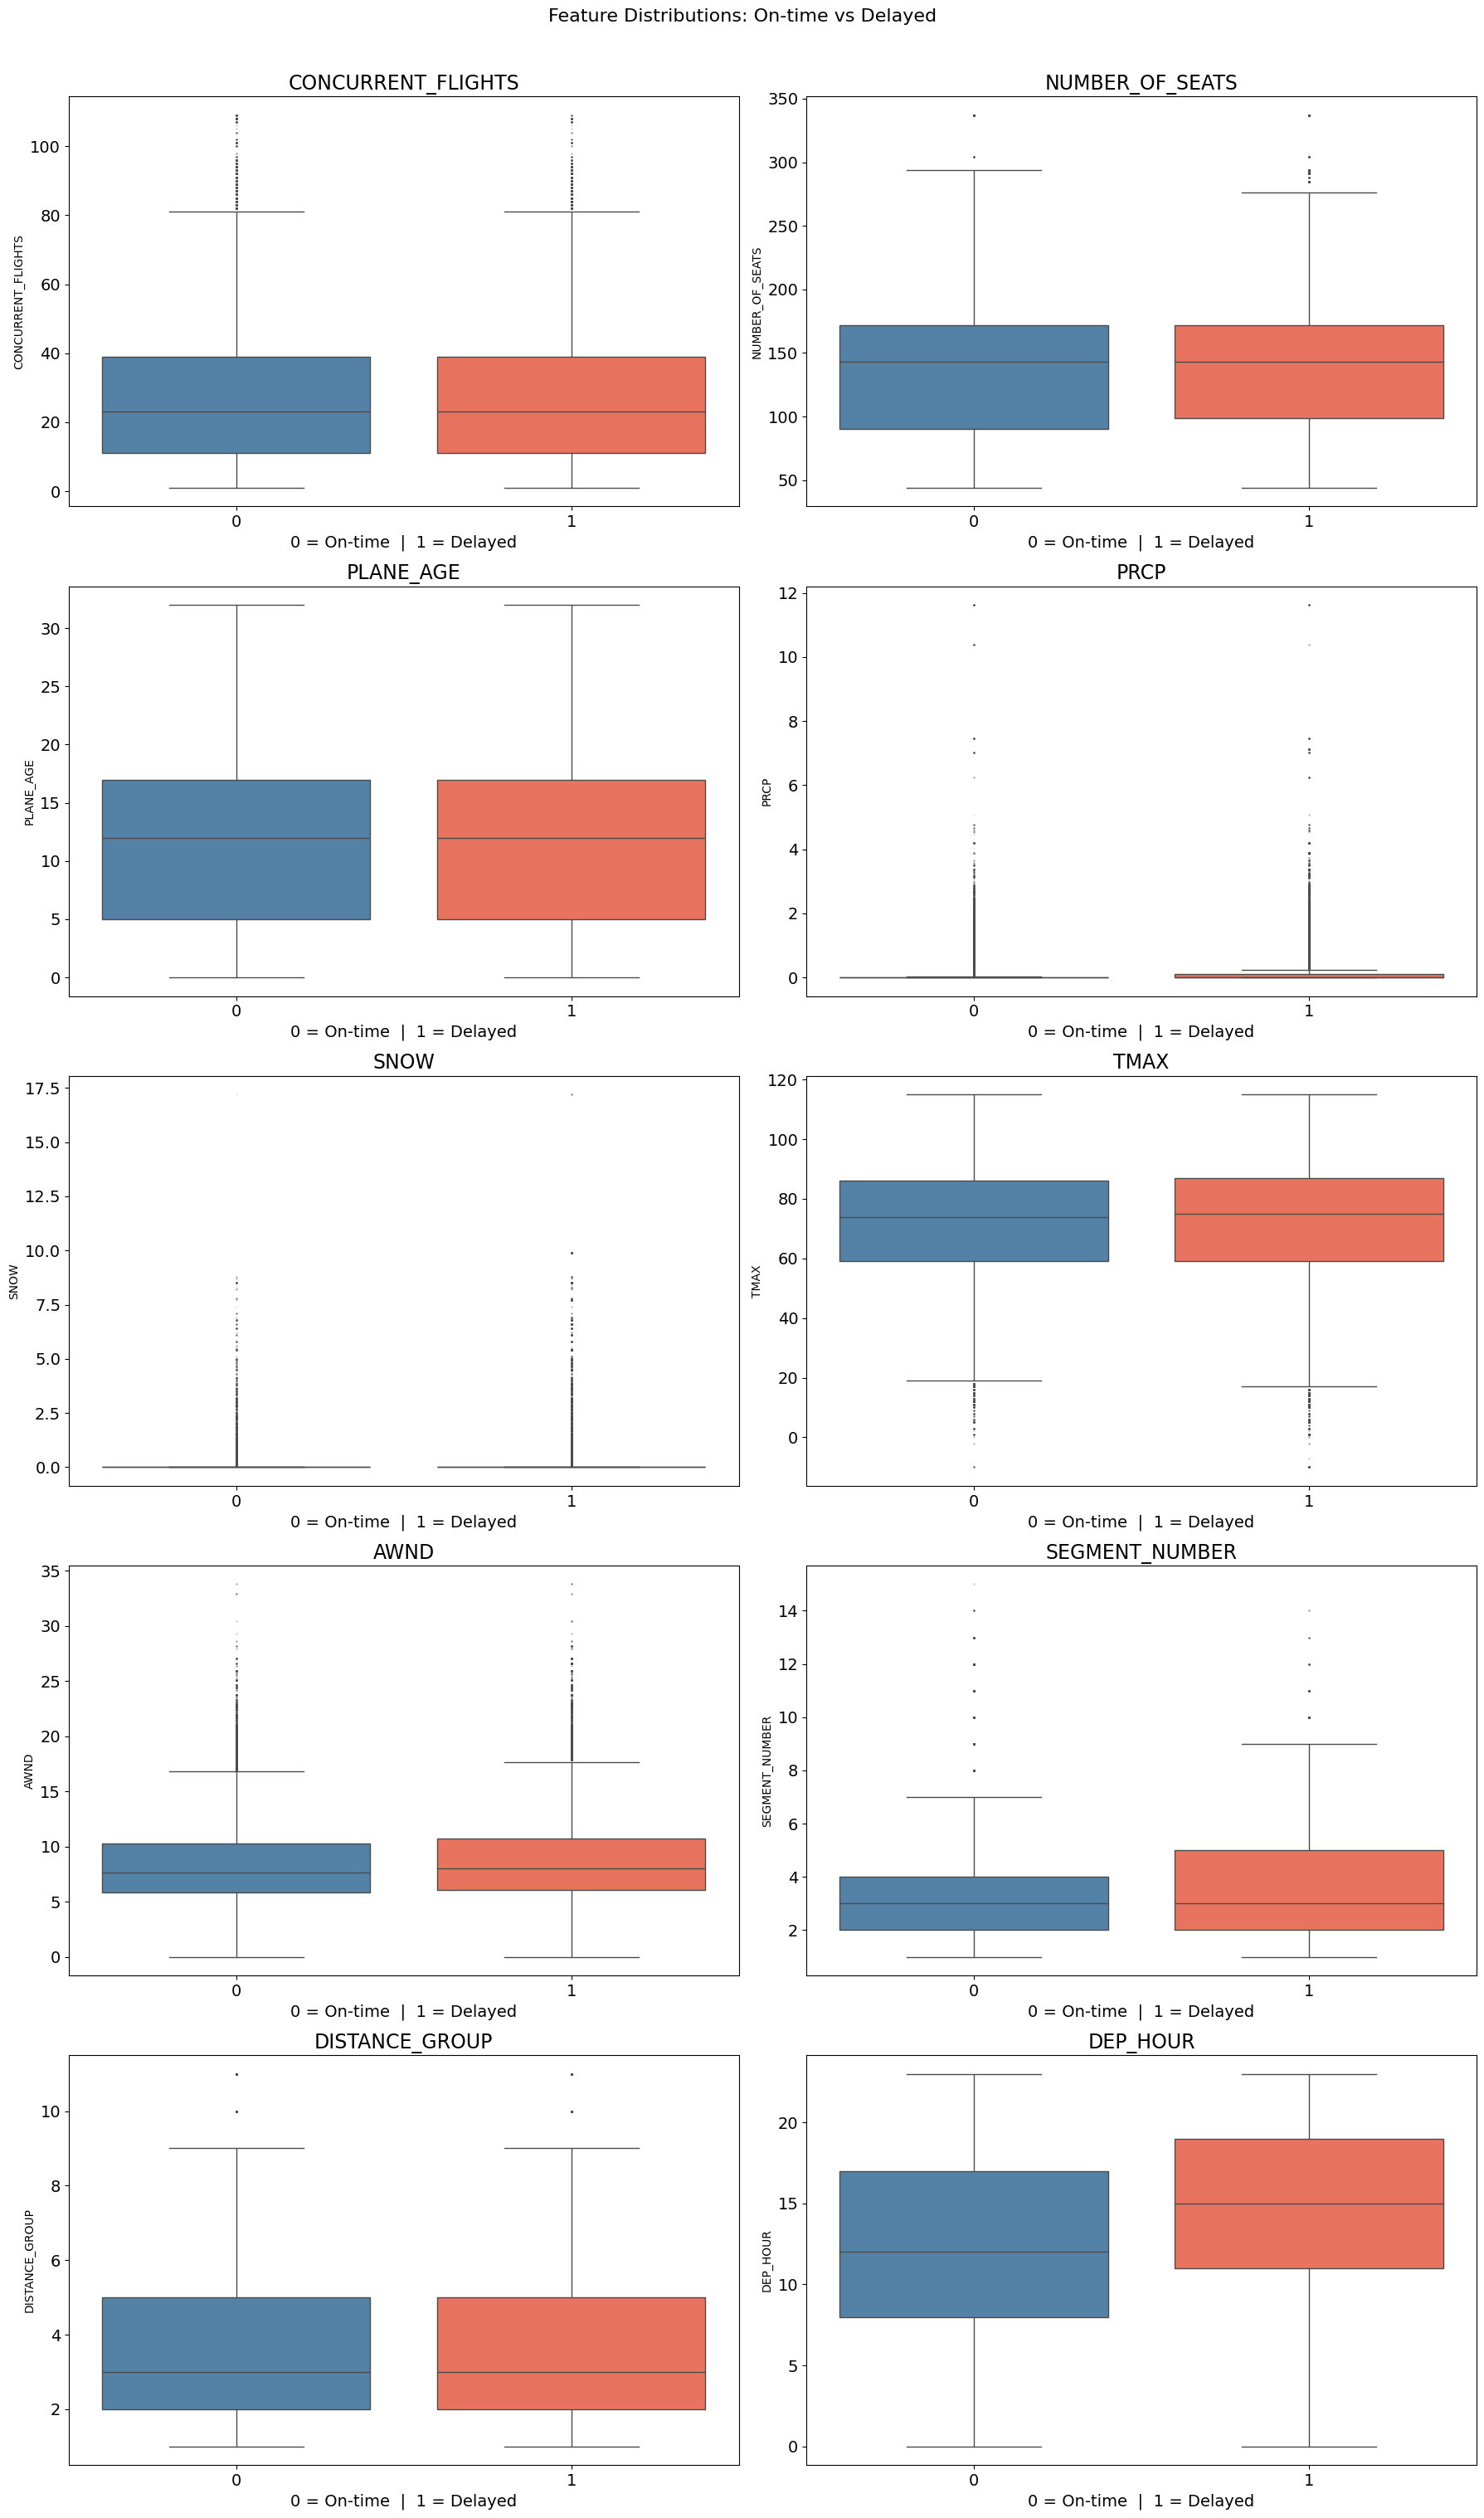

In [54]:
plot_delay_boxplots(df, BOXPLOT_COLS, ncols=2)

- The boxplots show that most numeric features have very similar distributions for on-time and delayed flights. The clearest visible differences are in DEP_HOUR, where delayed flights tend to depart later, and slightly in weather-related features such as PRCP, SNOW, and AWND.

- For SNOW, both classes are heavily concentrated at zero, meaning most flights happened with no snowfall. Delayed flights show a slightly denser upper tail, suggesting that snow events are rare but may be more associated with delays when they occur.

- Dive deeper into DEP_HOUR category 

In [74]:
def plot_boxplot_by_category(df, x_col, y_col, top_n=15,
                              sample_n=SAMPLE_N, figsize=(14, 5)):
    '''Boxplot of a numeric feature grouped by a categorical column.
    Sorted by median; top_n categories by flight count.
    Proportional stratified sample preserving 81/19 class ratio.'''
    on_time = df[df["DEP_DEL15"] == 0].sample(n=int(sample_n * 0.81), random_state=42)
    delayed = df[df["DEP_DEL15"] == 1].sample(n=int(sample_n * 0.19), random_state=42)
    sample  = pd.concat([on_time, delayed]).reset_index(drop=True)

    data = sample.copy()
    order = list(range(24))
    order = [x for x in order if x in data[x_col].values]

    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(
        data=data, x=x_col, y=y_col, order=order, ax=ax,
        hue=x_col, palette="muted", whis=1.5, legend=False,
        flierprops=dict(marker=".", markersize=1, alpha=0.2, linestyle="none"),
    )
    ax.set_title(f"{y_col} by {x_col}", fontsize=12)
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
    plt.tight_layout()
    plt.show()

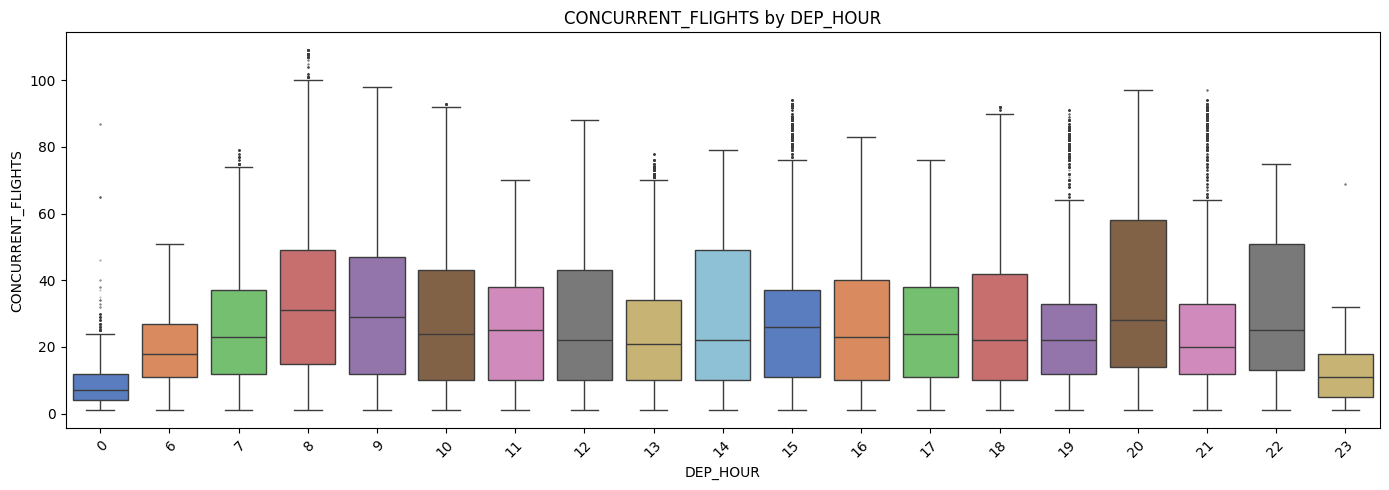

In [75]:
plot_boxplot_by_category(df, "DEP_HOUR", "CONCURRENT_FLIGHTS", top_n=24)

- Concurrent flights vary by departure hour. 
- The lowest congestion appears at night and very late hours, while morning and evening periods show higher medians and wider ranges, suggesting heavier airport traffic during peak operating hours.
